In [ ]:
# 1. Load the dataset
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv("spambase_csv.csv")
df = df.dropna()

X = df.drop(columns=['class'])
y = df['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

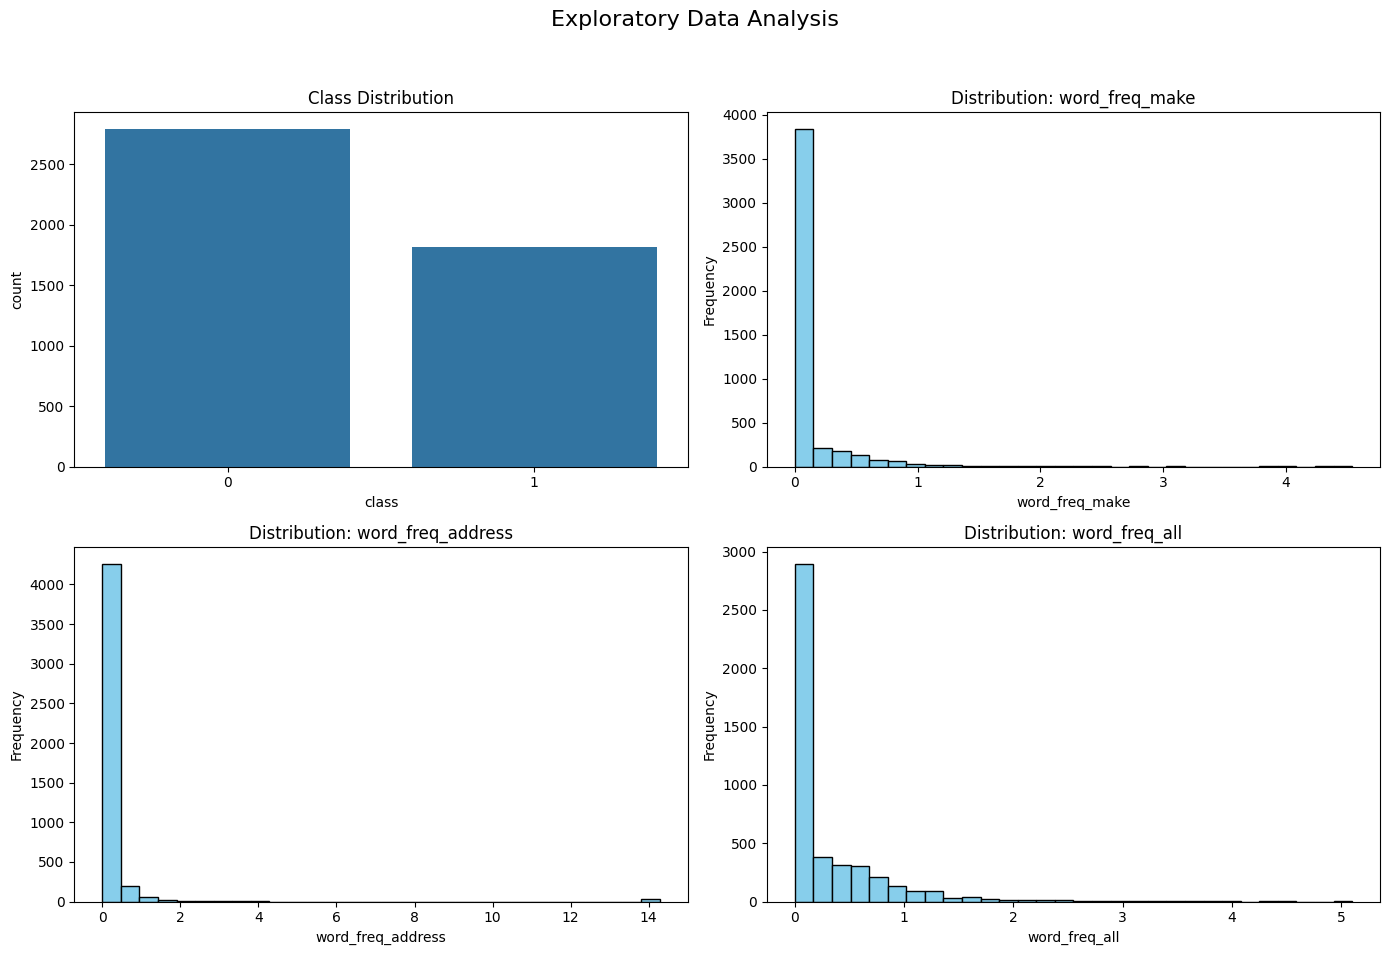

In [28]:
fig_eda, axes_eda = plt.subplots(2, 2, figsize=(14, 10))
fig_eda.suptitle('Exploratory Data Analysis', fontsize=16)

sns.countplot(x='class', data=df, ax=axes_eda[0, 0])
axes_eda[0, 0].set_title('Class Distribution')

features_to_plot = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'capital_run_length_average']
for i, feature in enumerate(features_to_plot):
    if i < 3: # Use remaining subplots
        ax = axes_eda.flatten()[i+1]
        ax.hist(df[feature], bins=30, color='skyblue', edgecolor='black')
        ax.set_title(f'Distribution: {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eda_plots.eps', format='eps')
plt.show()
plt.show()

C:\Users\raman\AppData\Local\Temp\ipykernel_28032\2361997272.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


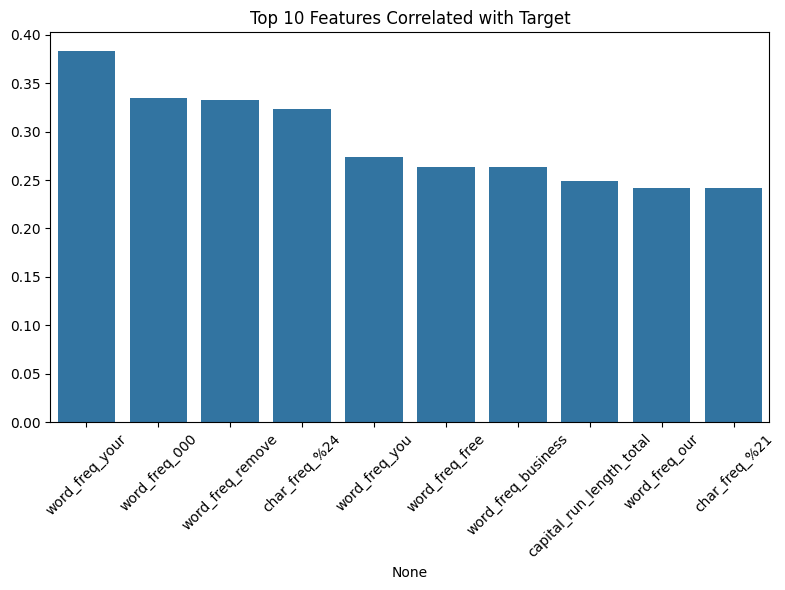

In [15]:
corr_with_target = df.corr()['class'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=corr_with_target.index[1:11], y=corr_with_target.values[1:11], ax=ax)
ax.set_title("Top 10 Features Correlated with Target")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig("correlation_target.eps", format='eps')
plt.show()
plt.close()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


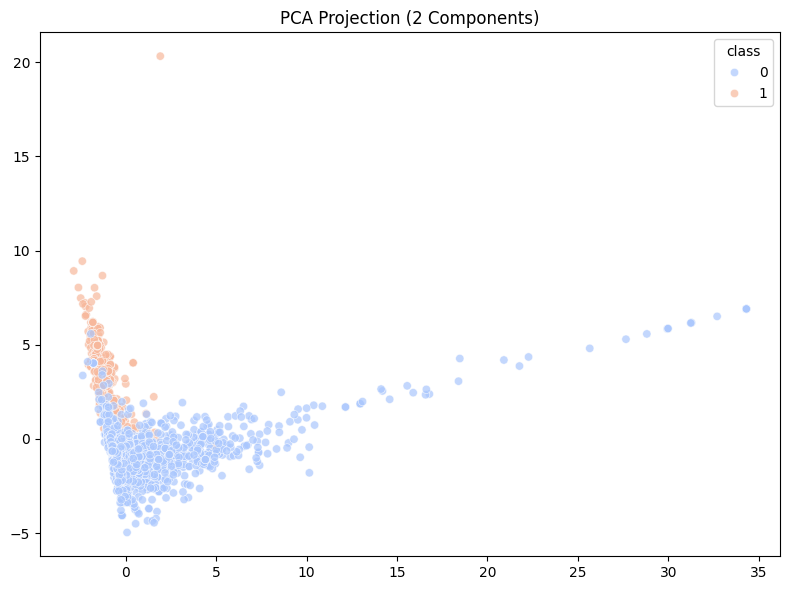

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="coolwarm", alpha=0.7, ax=ax)
ax.set_title("PCA Projection (2 Components)")
plt.tight_layout()
plt.savefig("pca_projection.eps", format='eps')
plt.show()
plt.close()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Baseline Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Baseline Logistic Regression Accuracy: 0.9294245385450597
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



In [20]:
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best Logistic Regression Score:", grid_lr.best_score_)


c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead

Best Logistic Regression Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best Logistic Regression Score: 0.9241847826086955


c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [21]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for k in kernels:
    svm_model = SVC(kernel=k)
    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_test)
    print(f"SVM ({k}) Accuracy:", accuracy_score(y_test, y_pred_svm))

# 8. Tune SVM hyperparameters
param_grid_svm = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # only relevant for poly kernel
}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)



SVM (linear) Accuracy: 0.9305103148751357
SVM (poly) Accuracy: 0.7795874049945711
SVM (rbf) Accuracy: 0.9272529858849077
SVM (sigmoid) Accuracy: 0.8838219326818675
Best SVM Params: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM Score: 0.9339673913043478


In [22]:
best_lr = grid_lr.best_estimator_
best_svm = grid_svm.best_estimator_

for model, name in [(best_lr, "Logistic Regression"), (best_svm, "SVM")]:
    y_pred = model.predict(X_test)
    print(f"\n{name} Evaluation:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Logistic Regression Evaluation:
Accuracy: 0.9305103148751357
Confusion Matrix:
 [[531  27]
 [ 37 326]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921


SVM Evaluation:
Accuracy: 0.9272529858849077
Confusion Matrix:
 [[533  25]
 [ 42 321]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       558
           1       0.93      0.88      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



In [23]:
cv_scores_lr = cross_val_score(best_lr, X_scaled, y, cv=5, scoring='accuracy')
cv_scores_svm = cross_val_score(best_svm, X_scaled, y, cv=5, scoring='accuracy')

print("\n5-Fold CV Logistic Regression:", cv_scores_lr, "Mean:", np.mean(cv_scores_lr))
print("5-Fold CV SVM:", cv_scores_svm, "Mean:", np.mean(cv_scores_svm))


c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instea


5-Fold CV Logistic Regression: [0.91856678 0.92826087 0.92826087 0.94021739 0.84130435] Mean: 0.9113220507010338
5-Fold CV SVM: [0.93268187 0.93369565 0.95       0.94891304 0.85      ] Mean: 0.9230581126374922


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


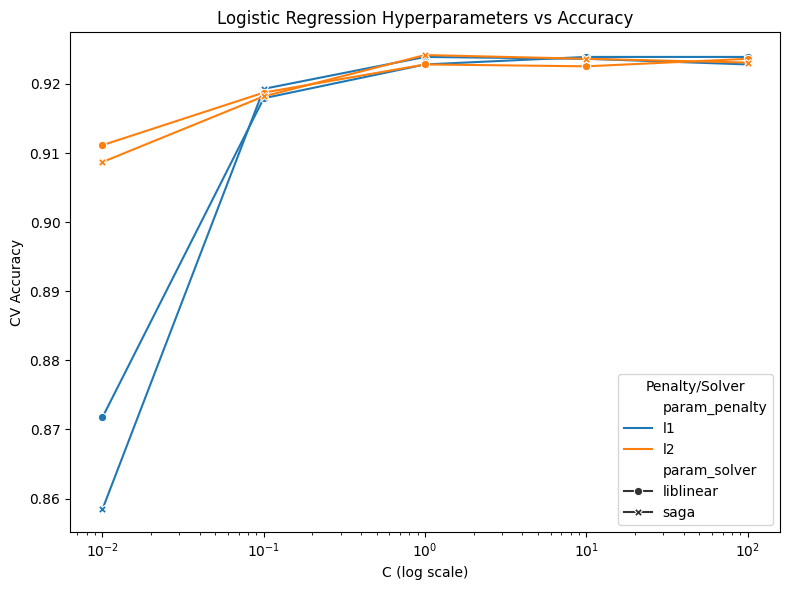

In [24]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Logistic Regression Hyperparameter Tuning Visualization ---
results_lr = pd.DataFrame(grid_lr.cv_results_)

plt.figure(figsize=(8,6))
sns.lineplot(
    data=results_lr,
    x="param_C",
    y="mean_test_score",
    hue="param_penalty",
    style="param_solver",
    markers=True, dashes=False
)
plt.xscale("log")
plt.title("Logistic Regression Hyperparameters vs Accuracy")
plt.xlabel("C (log scale)")
plt.ylabel("CV Accuracy")
plt.legend(title="Penalty/Solver")
plt.tight_layout()
plt.savefig("logreg_hyperparams_accuracy.eps", format='eps')
plt.show()
plt.close()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


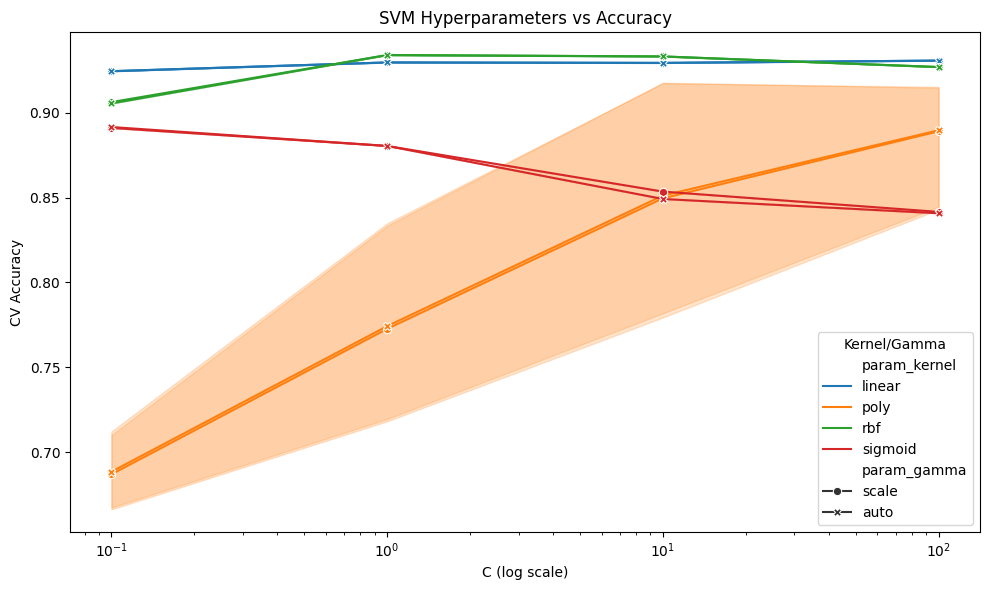

In [25]:
results_svm = pd.DataFrame(grid_svm.cv_results_)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=results_svm,
    x="param_C",
    y="mean_test_score",
    hue="param_kernel",
    style="param_gamma",
    markers=True, dashes=False
)
plt.xscale("log")
plt.title("SVM Hyperparameters vs Accuracy")
plt.xlabel("C (log scale)")
plt.ylabel("CV Accuracy")
plt.legend(title="Kernel/Gamma")
plt.tight_layout()
plt.savefig("svm_hyperparams_accuracy.eps", format='eps')
plt.show()
plt.close()

In [26]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    train_time = end - start
    print(f"\n{name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Training Time (s): {train_time:.4f}")
    return acc, prec, rec, f1, train_time

# Evaluate best Logistic Regression
metrics_lr = evaluate_model(best_lr, X_train, y_train, X_test, y_test, "Logistic Regression")

# Evaluate SVM kernels separately
kernel_results = []
for k in ['linear','poly','rbf','sigmoid']:
    svm_model = SVC(kernel=k, C=grid_svm.best_params_['C'], gamma=grid_svm.best_params_['gamma'])
    acc, prec, rec, f1, train_time = evaluate_model(svm_model, X_train, y_train, X_test, y_test, f"SVM-{k}")
    kernel_results.append([k, acc, f1, train_time])

# --- Kernel Performance Table ---
kernel_df = pd.DataFrame(kernel_results, columns=["Kernel","Accuracy","F1 Score","Training Time (s)"])
print("\nSVM Kernel Performance:\n", kernel_df)


c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression Metrics:
Accuracy: 0.9305
Precision: 0.9235
Recall: 0.8981
F1 Score: 0.9106
Training Time (s): 1.4252

SVM-linear Metrics:
Accuracy: 0.9305
Precision: 0.9235
Recall: 0.8981
F1 Score: 0.9106
Training Time (s): 0.2907

SVM-poly Metrics:
Accuracy: 0.7796
Precision: 0.9598
Recall: 0.4601
F1 Score: 0.6220
Training Time (s): 0.2107

SVM-rbf Metrics:
Accuracy: 0.9273
Precision: 0.9277
Recall: 0.8843
F1 Score: 0.9055
Training Time (s): 0.1078

SVM-sigmoid Metrics:
Accuracy: 0.8838
Precision: 0.8536
Recall: 0.8512
F1 Score: 0.8524
Training Time (s): 0.1420

SVM Kernel Performance:
     Kernel  Accuracy  F1 Score  Training Time (s)
0   linear  0.930510  0.910615           0.290737
1     poly  0.779587  0.621974           0.210684
2      rbf  0.927253  0.905501           0.107757
3  sigmoid  0.883822  0.852414           0.141970


In [27]:
cv_scores_lr = cross_val_score(best_lr, X_scaled, y, cv=5, scoring='accuracy')
cv_scores_svm = cross_val_score(best_svm, X_scaled, y, cv=5, scoring='accuracy')

cv_table = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Logistic Regression": cv_scores_lr,
    "SVM": cv_scores_svm
})
cv_table.loc["Average"] = ["Average", cv_scores_lr.mean(), cv_scores_svm.mean()]
print("\n5-Fold CV Results:\n", cv_table)


c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\raman\Documents\Financial health prediction\MLenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instea


5-Fold CV Results:
             Fold  Logistic Regression       SVM
0              1             0.918567  0.932682
1              2             0.928261  0.933696
2              3             0.928261  0.950000
3              4             0.940217  0.948913
4              5             0.841304  0.850000
Average  Average             0.911322  0.923058
